In [1]:
from src import Single_view_model
from src import View_Cancer_Dataloader

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms import functional as TF

In [2]:
dataloader = View_Cancer_Dataloader(
    root_folder='/Users/jazav7774/Data/Mammo/',
    annotation_csv="modified_breast-level_annotations.csv",
    imagefolder_path="images_png_396",
    image_format="png",
    norm_kind="dataset_zscore",
    batch_size=32,  
    num_workers=1,
    task=1,
    use_train_sampler=False, 
)
model = Single_view_model(task=1, drop=0.5, weights_file='/Users/jazav7774/UiT/FYS-8603/checkpoints/One_view_resnet.ckpt', num_class=2)

In [6]:
def visualize_grad_cam(model, image_tensor, target_class=None, cmap='jet', 
                       denormalize=True, mean=108.3328, std=69.6431):
    """
    Visualize Grad-CAM heatmap overlaid on the input image.
    
    Args:
        model: Single_view_model instance
        image_tensor: Input image tensor of shape (1, 3, H, W) or (3, H, W)
        target_class: Target class for computing gradients. If None, uses predicted class.
        cmap: Colormap for the heatmap
        denormalize: Whether to denormalize the image (default: True)
        mean: Mean used for normalization (default: 108.3328 for png dataset_zscore)
        std: Std used for normalization (default: 69.6431 for png dataset_zscore)
    
    Returns:
        fig: Matplotlib figure with the visualization
    """
    # Ensure input has batch dimension
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    
    # Only process the first image if batch size > 1
    if image_tensor.shape[0] > 1:
        image_tensor = image_tensor[0:1]
    
    # Generate Grad-CAM
    grad_cam = model.generate_grad_cam(image_tensor, target_class)
    
    # Get the original image for display and denormalize
    image_np = image_tensor[0].detach().permute(1, 2, 0).cpu().numpy()
    
    # Denormalize using dataset statistics
    if denormalize:
        image_np = image_np * std + mean
        # Normalize to [0, 1] for display
        image_np = image_np / 255.0
        image_np = np.clip(image_np, 0, 1)
    
    # Resize grad_cam to match image size
    grad_cam_resized = torch.nn.functional.interpolate(
        grad_cam.unsqueeze(1), 
        size=(image_np.shape[0], image_np.shape[1]), 
        mode='bilinear', 
        align_corners=False
    )
    grad_cam_resized = grad_cam_resized.squeeze(1)[0].numpy()
    
    # Get prediction
    with torch.no_grad():
        model.eval()
        output = model(image_tensor.detach())
        prediction = output.argmax(dim=1)[0]
        confidence = torch.softmax(output, dim=1)[0, prediction].item()
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Grad-CAM heatmap
    im1 = axes[1].imshow(grad_cam_resized, cmap=cmap)
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    # Overlay
    axes[2].imshow(image_np, cmap='gray')
    im2 = axes[2].imshow(grad_cam_resized, cmap=cmap, alpha=0.5)
    axes[2].set_title(f'Overlay (Pred: Class {prediction.item()}, Conf: {confidence:.3f})')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    
    return fig

In [7]:
images, labels, densities = next(iter(dataloader.test_dataloader()))



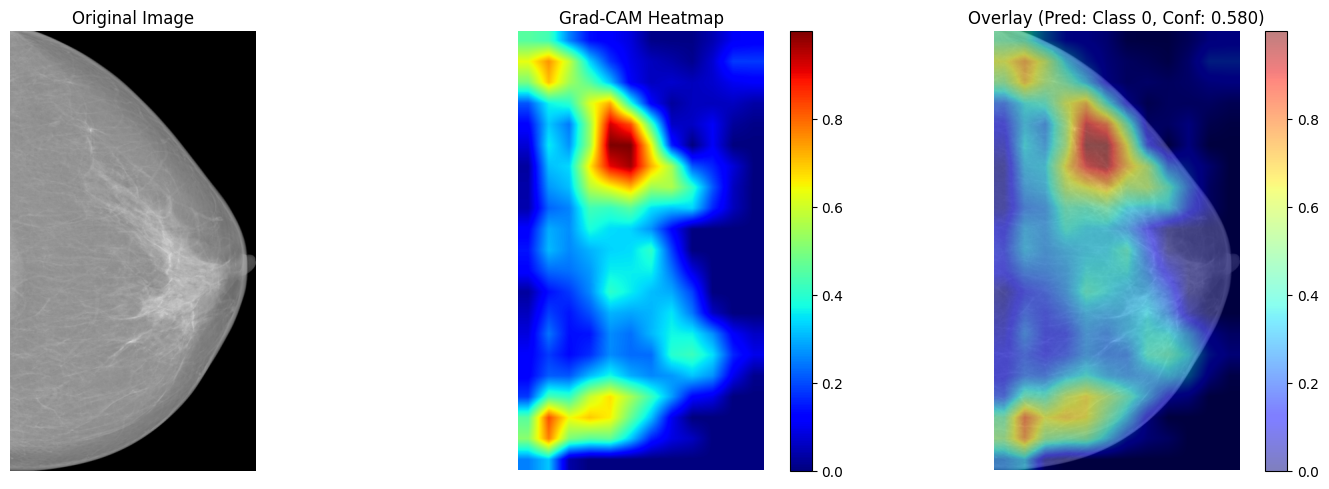

In [8]:
# Visualize Grad-CAM
fig = visualize_grad_cam(model, images)
plt.show()